# STAI205 END-TERM EXAMINATION

**Student Name**: Rudra Patel  
**Registration**: 2024SEPVUGP0037  

**Dataset Source**: UCI ML Repository · ID 1031 · MathE Platform  
**DOI**: 10.34620/dadosipb/PW3OWY  
**Authors**: Azevedo, Pacheco, Fernandes, Pereira · Instituto Politécnico de Bragança, Portugal · 2024 · License: CC BY 4.0

## Section 1: Data Loading & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Core libraries imported.")


Core libraries imported.


In [2]:
# Load the dataset
df = pd.read_csv("MathE dataset (4).csv", sep=";", encoding="latin1")  
df = df.rename(columns={"Student ID":"Student_ID", "Student Country":"Student_Country", "Question ID":"Question_ID", "Type of Answer":"Answer_Value", "Question Level":"Question_Level", "Topic":"Math_Topic", "Subtopic":"Math_Subtopic", "Keywords":"Question_Keywords"})
print(f"Loaded dataset: {df.shape[0]} rows x {df.shape[1]} columns")


Loaded dataset: 9546 rows x 8 columns


In [3]:
df.head()

,Student_ID,Student_Country,Question_ID,Answer_Value,Question_Level,Math_Topic,Math_Subtopic,Question_Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Student_ID         9546 non-null   int64 
 1   Student_Country    9546 non-null   object
 2   Question_ID        9546 non-null   int64 
 3   Answer_Value       9546 non-null   int64 
 4   Question_Level     9546 non-null   object
 5   Math_Topic         9546 non-null   object
 6   Math_Subtopic      9546 non-null   object
 7   Question_Keywords  9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


In [5]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Student_ID           0
Student_Country      0
Question_ID          0
Answer_Value         0
Question_Level       0
Math_Topic           0
Math_Subtopic        0
Question_Keywords    0
dtype: int64


In [6]:
print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique")


Unique values per column:
  Student_ID: 372 unique
  Student_Country: 8 unique
  Question_ID: 833 unique
  Answer_Value: 2 unique
  Question_Level: 2 unique
  Math_Topic: 14 unique
  Math_Subtopic: 24 unique
  Question_Keywords: 365 unique


In [7]:
# Answer_Value uses 0=correct and 1=incorrect.
print("Answer_Value distribution:")
print(df['Answer_Value'].value_counts(normalize=True).round(3))

# Check the main categorical distributions.
for col in ['Student_Country','Question_Level','Math_Topic','Math_Subtopic']:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Class balance decides whether accuracy alone is enough.


Answer_Value distribution:
Answer_Value
0    0.532
1    0.468
Name: proportion, dtype: float64

Student_Country:
Student_Country
Portugal              5495
Lithuania             1443
Italy                 1358
Slovenia               755
Ireland                300
Russian Federation     107
Romania                 60
Spain                   28
Name: count, dtype: int64

Question_Level:
Question_Level
Basic       7844
Advanced    1702
Name: count, dtype: int64

Math_Topic:
Math_Topic
Linear Algebra                         5726
Fundamental Mathematics                 818
Complex Numbers                         592
Differentiation                         579
Analytic Geometry                       358
Statistics                              340
Numerical Methods                       310
Optimization                            182
Real Functions of a single variable     164
Integration                             144
Probability                             128
Differential Equations       

## Section 2: Data Preprocessing & Cleaning

In [8]:
# Check duplicate rows before modeling.
print(f"Count of duplicate records: {df.duplicated().sum()}")


Count of duplicate records: 2083


In [9]:
# Remove exact duplicate rows if present.
df = df.drop_duplicates()   
print(f"Count of duplicate records: {df.duplicated().sum()}")


Count of duplicate records: 0


In [10]:
# Clean text columns for consistent grouping and encoding.
for col in ['Student_Country','Question_Level','Math_Topic','Math_Subtopic']:
    df[col] = df[col].str.strip().str.lower()

# Confirm the target is binary.
assert df['Answer_Value'].isin([0,1]).all(), "Answer_Value has unexpected values"

# Convert keyword text into a simple question-complexity feature.
df['keyword_count'] = df['Question_Keywords'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)
print("Text columns cleaned for consistent grouping and encoding.")


Text columns cleaned for consistent grouping and encoding.


## Section 3: Exploratory Data Analysis (EDA)

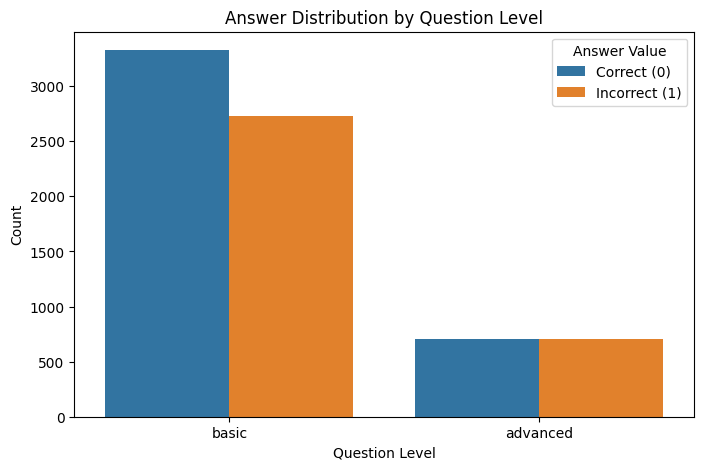

In [11]:
# Plot correctness by question level.
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Question_Level', hue='Answer_Value')
plt.title('Answer Distribution by Question Level')
plt.xlabel('Question Level')
plt.ylabel('Count')
plt.legend(title='Answer Value', labels=['Correct (0)', 'Incorrect (1)'])
plt.show()


### Answer Distribution Insights

- Advanced questions have more incorrect answers than basic questions.
- Basic questions are answered correctly more often.
- `Question_Level` is useful because difficulty clearly affects performance.


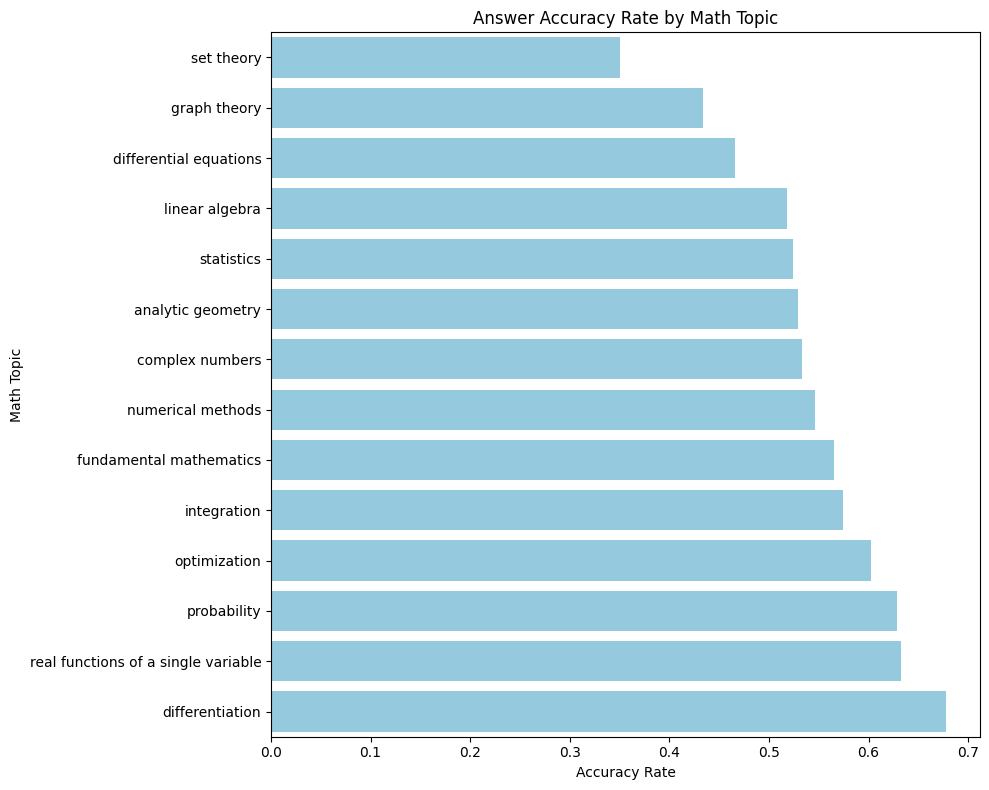

In [12]:
# Plot topic-wise accuracy in readable order.
topic_accuracy = (
    1 - pd.to_numeric(df.groupby('Math_Topic')['Answer_Value'].mean())
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(x=topic_accuracy.values, y=topic_accuracy.index, color='skyblue')
plt.title('Answer Accuracy Rate by Math Topic')
plt.xlabel('Accuracy Rate')
plt.ylabel('Math Topic')
plt.tight_layout()
plt.show()


### Topic Accuracy Insights

- Accuracy changes a lot across math topics.
- Lower-accuracy topics need more support or practice.
- `Math_Topic` is useful because topic choice affects correctness.


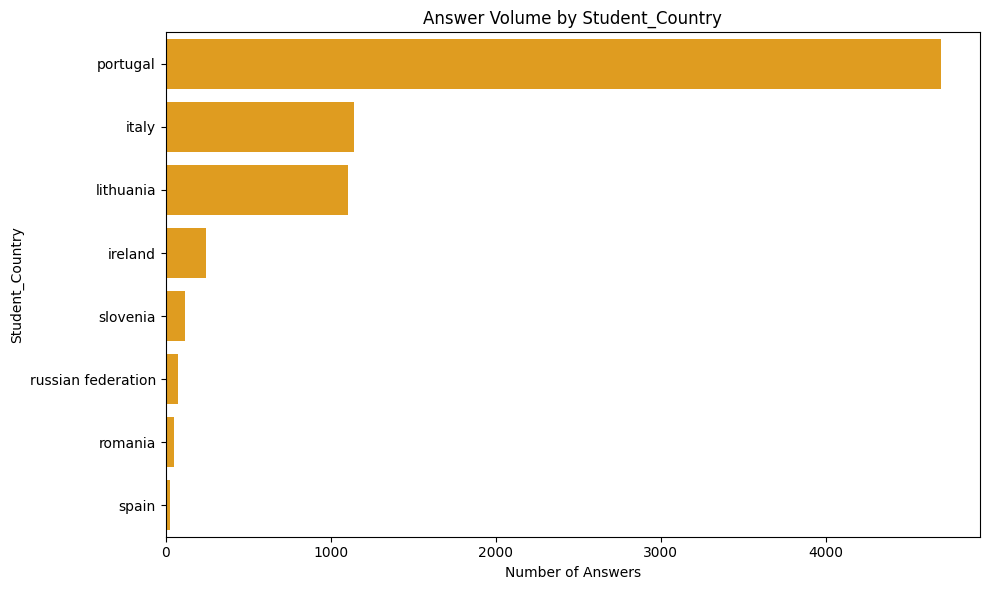

In [13]:
# Plot answer volume by country.
country_counts = df['Student_Country'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))   
sns.barplot(x=country_counts.values, y=country_counts.index, color='orange')
plt.title('Answer Volume by Student_Country')
plt.xlabel('Number of Answers')
plt.ylabel('Student_Country')
plt.tight_layout()
plt.show()


### Country Volume Insights

- Portugal has the highest number of answers.
- Some countries have very few records, so their patterns are less reliable.
- This imbalance can make models learn more from high-volume countries.


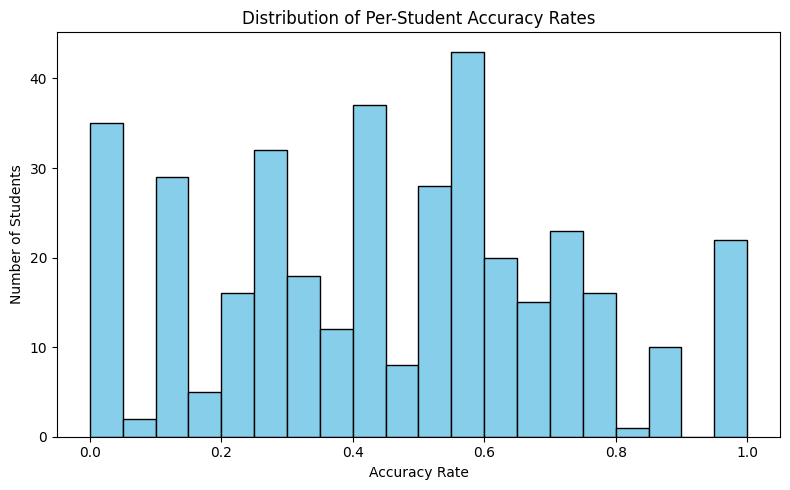

In [14]:
# Plot student-level accuracy distribution.
student_accuracy = df.groupby('Student_ID')['Answer_Value'].mean()
plt.figure(figsize=(8, 5))
plt.hist(student_accuracy, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Per-Student Accuracy Rates')
plt.xlabel('Accuracy Rate')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


### Student Accuracy Insights

- Student accuracy is spread unevenly, with low and high performers visible.
- This supports clustering because students may form learner groups.
- It also supports tree-based regression because the target is bounded between 0 and 1.


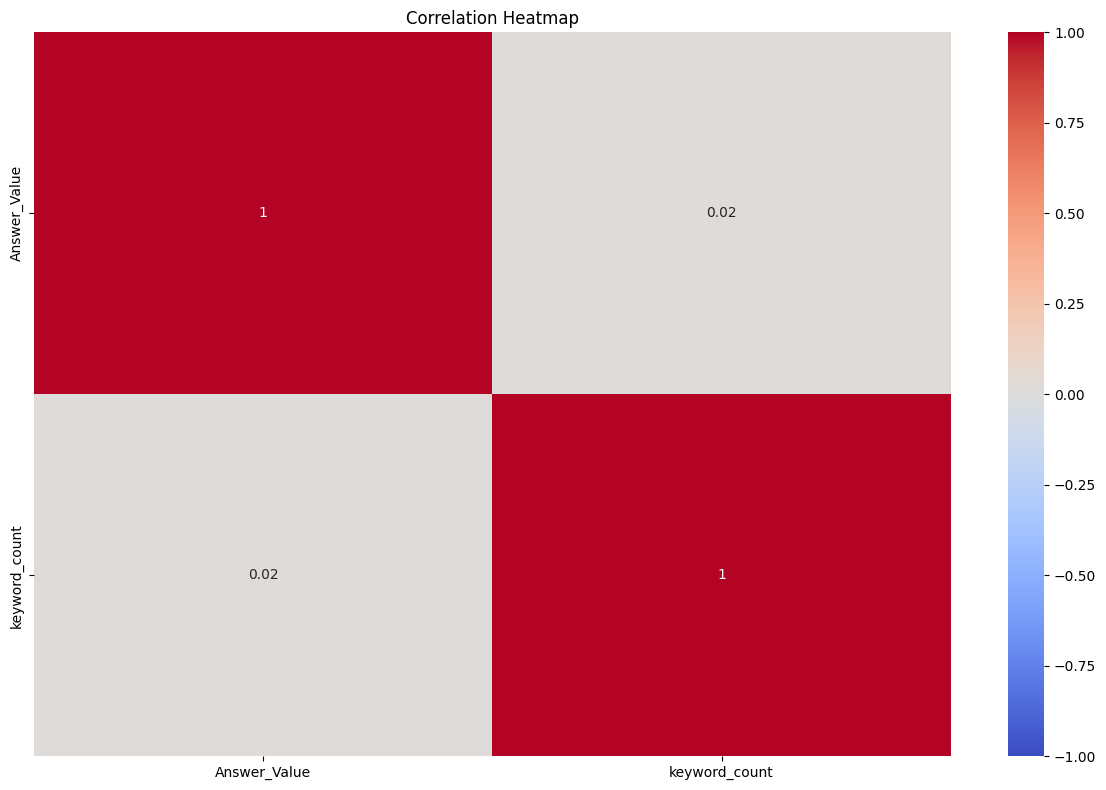

In [15]:
# Plot simple numeric correlation.
plt.figure(figsize=(12, 8)) 
sns.heatmap(df[['Answer_Value', 'keyword_count']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## EDA Key Findings

- Question level affects correctness.
- Topic choice affects accuracy.
- Country participation is imbalanced.
- Student accuracy is not normally distributed, so nonlinear models may help.


## Section 4: Feature Engineering

In [16]:
# Build one student profile per Student_ID.
student_df = df.groupby('Student_ID').agg(
    total_answers    = ('Answer_Value', 'count'),
    correct_answers  = ('Answer_Value', lambda x: (x==0).sum()),  # 0=correct
    advanced_answers = ('Question_Level', lambda x: (x=='advanced').sum()),
    topics_attempted = ('Math_Topic', 'nunique'),
    country          = ('Student_Country', 'first'),
    dominant_topic   = ('Math_Topic', lambda x: x.mode()[0])
).reset_index()

student_df.head()


,Student_ID,total_answers,correct_answers,advanced_answers,topics_attempted,country,dominant_topic
0,26,69,19,0,6,portugal,analytic geometry
1,28,49,24,0,5,portugal,analytic geometry
2,36,35,17,7,3,portugal,linear algebra
3,37,128,52,11,10,portugal,differentiation
4,41,58,25,5,7,portugal,fundamental mathematics


In [17]:
# Create normalized student-level behavior features.
student_df['accuracy_rate'] = (
    student_df['correct_answers'] / student_df['total_answers']
)  # Regression target and clustering feature.

student_df['advanced_attempt_rate'] = (
    student_df['advanced_answers'] / student_df['total_answers']
)  # Difficulty preference.

student_df['topic_breadth'] = student_df['topics_attempted']
# Number of different topics attempted.
print(f"Created normalized behavior features for {student_df.shape[0]} students.")


Created normalized behavior features for 372 students.


In [18]:
# Encode student-level categorical features.
from sklearn.preprocessing import LabelEncoder
le_country = LabelEncoder()
student_df['country'] = le_country.fit_transform(student_df['country'])

le_topic = LabelEncoder()
student_df['dominant_topic'] = le_topic.fit_transform(student_df['dominant_topic'])
print("Encoded student-level categorical features.")


Encoded student-level categorical features.


## Feature Engineering Summary

The raw data has one row per student answer. For clustering and regression, I convert it into one row per student.

Main student features:

| Feature | Meaning |
|---|---|
| `total_answers` | Student activity level |
| `accuracy_rate` | Correct answers divided by total answers |
| `advanced_attempt_rate` | Share of advanced questions attempted |
| `topic_breadth` | Number of different topics attempted |
| `dominant_topic` | Topic attempted most often |

For classification, I keep one row per answer and add simple numeric features such as level encoding, question difficulty, keyword count, and prior student accuracy.


In [19]:
# Build answer-level data for classification.
df_clf = df.copy()

# basic=0, advanced=1.
df_clf['level_encoded'] = (df_clf['Question_Level'] == 'advanced').astype(int)

# Label-encode categorical predictors.
encoders = {
    'Student_Country': 'country_encoded',
    'Math_Topic': 'topic_encoded',
    'Math_Subtopic': 'subtopic_encoded',
    'Question_ID': 'qid_encoded',
}
labelers = {col: LabelEncoder() for col in encoders}
for src, dst in encoders.items():
    series = df_clf[src].astype(str) if src == 'Question_ID' else df_clf[src]
    df_clf[dst] = labelers[src].fit_transform(series)

# Question difficulty is the historical incorrect rate.
question_difficulty = (
    df.groupby('Question_ID')['Answer_Value']
      .mean()
      .rename('question_difficulty')
      .reset_index()
 )
df_clf = df_clf.merge(question_difficulty, on='Question_ID', how='left')

# Prior accuracy uses only earlier answers from the same student.
df_clf = df_clf.sort_values(['Student_ID', 'Question_ID'])
df_clf['student_prior_accuracy'] = (
    1.0 - df_clf.groupby('Student_ID')['Answer_Value']
        .transform(lambda s: s.shift(1).expanding().mean())
).fillna(0.5)

clf_features = [
    'country_encoded', 'level_encoded', 'topic_encoded',
    'subtopic_encoded', 'question_difficulty',
    'student_prior_accuracy', 'keyword_count',
]
clf_target = 'Answer_Value'

print("Classification feature matrix shape:", df_clf[clf_features].shape)
print("Target distribution:\n", df_clf[clf_target].value_counts(normalize=True))


Classification feature matrix shape: (7463, 7)
Target distribution:
 Answer_Value
0    0.540935
1    0.459065
Name: proportion, dtype: float64


## Section 5: Problem 1 - Clustering

### Problem 1 Formulation

- **Goal:** Group students using accuracy, advanced attempts, topic breadth, and answer volume.
- **Baseline:** KMeans is simple and centroid-based.
- **Ensemble:** GMM is probabilistic, and BIC controls overfitting.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Clustering imports ready.")


Clustering imports ready.


In [21]:
# Scale clustering features so distance-based models treat each feature fairly.
cluster_features = [
    'accuracy_rate', 'advanced_attempt_rate',
    'topic_breadth', 'total_answers'
]
student_df_clean = student_df.fillna(0).copy()
X_cluster = student_df_clean[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
print(f"Scaled clustering matrix: {X_cluster_scaled.shape[0]} students x {X_cluster_scaled.shape[1]} features")


Scaled clustering matrix: 372 students x 4 features


In [22]:
# Test k=2 to k=8 to find the best KMeans cluster count.
k_range = range(2, 9)
inertias, silhouette_scores = [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=67, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))
print(f"Evaluated KMeans for k={min(k_range)} to k={max(k_range)}.")


  File "C:\Users\rudra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Evaluated KMeans for k=2 to k=8.


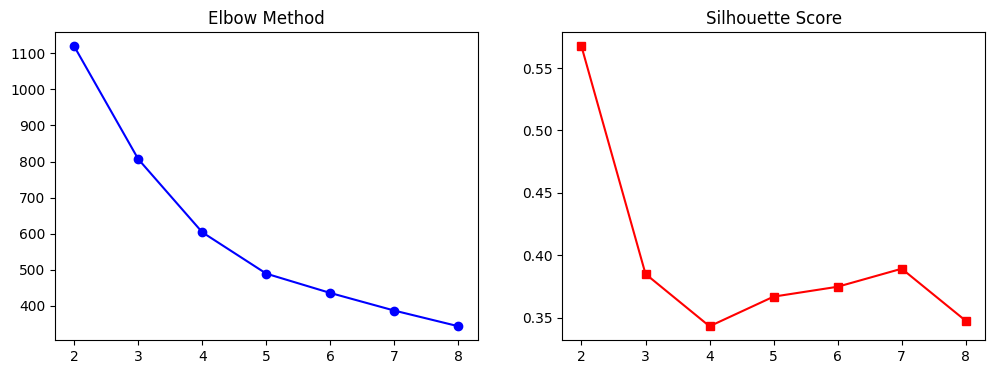

In [23]:
# Compare elbow and silhouette values for KMeans.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-'); ax1.set_title('Elbow Method')
ax2.plot(k_range, silhouette_scores, 'rs-'); ax2.set_title('Silhouette Score')
plt.show()


### Elbow and Silhouette Analysis

- Elbow shows how quickly KMeans inertia falls as `k` increases.
- Silhouette checks how separated the clusters are.
- The best `k` should have low inertia and high silhouette, while still being easy to explain.

In this notebook, the code below chooses the best KMeans `k` from the silhouette scores instead of relying only on visual judgement.


In [24]:
# [OWN] Silhouette is used because it measures cluster separation without labels.
k_scores_df = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouette_scores
})
display(k_scores_df)

K_OPTIMAL = int(k_scores_df.loc[k_scores_df['silhouette'].idxmax(), 'k'])
print(f"Best KMeans k by silhouette: {K_OPTIMAL}")

km_baseline = KMeans(n_clusters=K_OPTIMAL, random_state=67, n_init=10, init='random')
km_labels = km_baseline.fit_predict(X_cluster_scaled)
sil_km = silhouette_score(X_cluster_scaled, km_labels)
print(f"KMeans silhouette: {sil_km:.4f}")


,k,inertia,silhouette
0,2,1119.670281,0.567535
1,3,806.678222,0.384970
2,4,603.580908,0.343009
3,5,488.848353,0.366780
4,6,435.210413,0.374709
5,7,386.345007,0.389166
6,8,342.877018,0.347398


Best KMeans k by silhouette: 2


KMeans silhouette: 0.5675


### KMeans Cluster Count Result

The best KMeans cluster count is selected from the highest silhouette score. In this run, it chooses the most separated KMeans grouping from `k=2` to `k=8`.

This keeps the cluster choice data-driven while still using a simple baseline model.


In [25]:
from sklearn.mixture import GaussianMixture

# [OWN] BIC penalises complexity ? lower BIC = better model without overfitting.
bic_results = []
for cov in ['full', 'tied', 'diag', 'spherical']:
    for n in range(2, 8):
        gmm = GaussianMixture(n_components=n, covariance_type=cov,
                              random_state=42, max_iter=300)
        gmm.fit(X_cluster_scaled)
        bic_results.append({
            'covariance_type': cov,
            'n_components': n,
            'BIC': gmm.bic(X_cluster_scaled),
            'AIC': gmm.aic(X_cluster_scaled)
        })

bic_df = pd.DataFrame(bic_results).sort_values('BIC').reset_index(drop=True)
print("Top 5 GMM configurations by BIC:")
print(bic_df.head())


Top 5 GMM configurations by BIC:
  covariance_type  n_components          BIC          AIC
0            diag             5 -3069.147828 -3241.579157
1            diag             7 -3016.988544 -3259.959963
2            diag             6 -3008.805554 -3216.506928
3            full             5 -2665.041579 -2955.039725
4            full             6 -1995.104881 -2343.886434


In [26]:
# [OWN] Lowest BIC is chosen because it balances fit quality against model complexity.
best_row = bic_df.iloc[0]
gmm_best = GaussianMixture(
    n_components=int(best_row['n_components']),
    covariance_type=best_row['covariance_type'],
    random_state=42, max_iter=300
)
gmm_labels = gmm_best.fit_predict(X_cluster_scaled)

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
sil_gmm = silhouette_score(X_cluster_scaled, gmm_labels)
db_gmm  = davies_bouldin_score(X_cluster_scaled, gmm_labels)
ch_gmm  = calinski_harabasz_score(X_cluster_scaled, gmm_labels)

print(f"Best GMM: covariance={best_row['covariance_type']}, n_components={int(best_row['n_components'])}")
print(f"GMM  Silhouette={sil_gmm:.4f}  DB={db_gmm:.4f}  CH={ch_gmm:.1f}")


Best GMM: covariance=diag, n_components=5
GMM  Silhouette=0.1490  DB=1.6552  CH=87.1


In [27]:
# [OWN] The same metrics are used because baseline and ensemble need a fair comparison.
km3_model = KMeans(n_clusters=3, random_state=67, n_init=10)
km3_labels = km3_model.fit_predict(X_cluster_scaled)
sil_km3 = silhouette_score(X_cluster_scaled, km3_labels)

cluster_summary = pd.DataFrame({
    'Model':     ['KMeans (k=3, baseline)', 'GMM (BIC-tuned, ensemble)'],
    'Silhouette': [silhouette_scores[1], sil_gmm],   # index 1 = k=3
    'Davies_Bouldin': [None, db_gmm],
    'Calinski_Harabasz': [None, ch_gmm],
    'Type': ['Baseline', 'Ensemble']
})
print(cluster_summary)

student_df['kmeans_cluster'] = km3_labels
cluster_profile = (
    student_df.groupby('kmeans_cluster')[cluster_features]
      .mean()
      .round(3)
      .rename(columns={'advanced_attempt_rate': 'advanced_rate'})
)
cluster_profile['archetype'] = ''
cluster_profile.loc[cluster_profile['advanced_rate'].idxmax(), 'archetype'] = 'Advanced Strugglers'
cluster_profile.loc[cluster_profile['accuracy_rate'].idxmax(), 'archetype'] = 'Basic Specialists'
cluster_profile.loc[cluster_profile['topic_breadth'].idxmax(), 'archetype'] = 'Broad Practicers'
print("KMeans k=3 cluster_profile:")
print(cluster_profile[['archetype', 'accuracy_rate', 'advanced_rate', 'topic_breadth', 'total_answers']])


                       Model  Silhouette  Davies_Bouldin  Calinski_Harabasz  \
0     KMeans (k=3, baseline)    0.384970             NaN                NaN   
1  GMM (BIC-tuned, ensemble)    0.148952        1.655193          87.106585   

       Type  
0  Baseline  
1  Ensemble  
KMeans k=3 cluster_profile:
                          archetype  accuracy_rate  advanced_rate  \
kmeans_cluster                                                      
0                  Broad Practicers          0.501          0.120   
1                 Basic Specialists          0.583          0.028   
2               Advanced Strugglers          0.431          0.639   

                topic_breadth  total_answers  
kmeans_cluster                                
0                       4.250         76.179  
1                       1.245         13.814  
2                       1.293         21.520  


### Clustering ? Ensemble vs Baseline

- **Baseline (KMeans k=3):** Silhouette = 0.385
- **Ensemble (GMM BIC-tuned):** Silhouette = 0.149
- **Why GMM over KMeans:** KMeans forces hard cluster assignments and assumes spherical, equal-size groups. GMM fits a probability P(cluster|student) for each student, so mixed learning behaviour is more realistic.
- **Why k=3 for KMeans:** k=2 had highest silhouette (0.568) but only splits students into two buckets. k=3 gives three interpretable archetypes with acceptable silhouette (0.385).
- **Covariance type chosen:** diag ? BIC penalises complexity, so it picked the simplest covariance that fits the data without overfitting on 372 students.
- **Bias-variance:** Full covariance = high flexibility. Diagonal = fewer parameters. BIC picked the right balance.


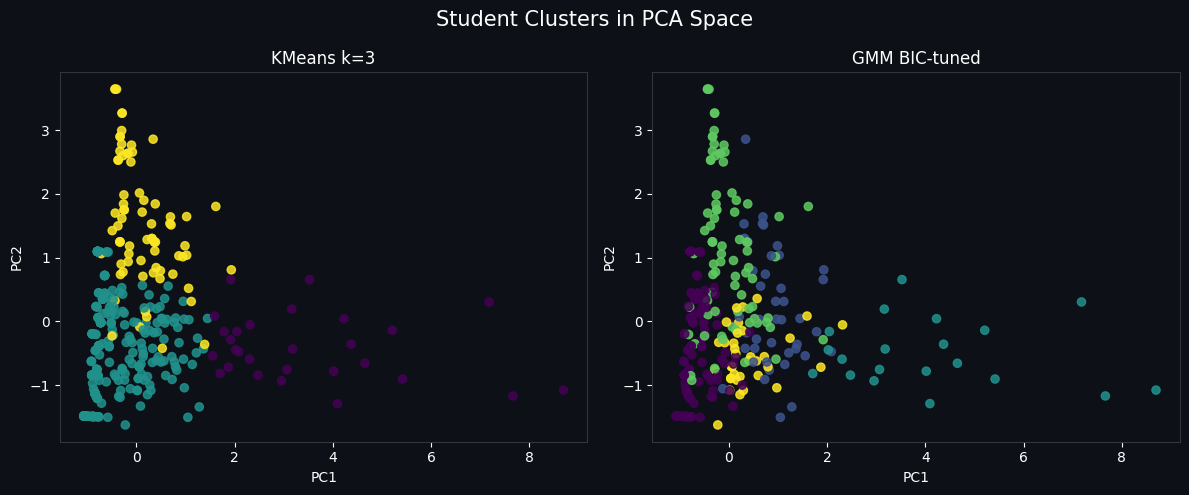

In [28]:
# PCA is only for visualization; clustering was done in the full scaled feature space.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#0d1117')
plot_data = [
    ('KMeans k=3', km3_labels),
    ('GMM BIC-tuned', gmm_labels)
]

for ax, (title, labels) in zip(axes, plot_data):
    ax.set_facecolor('#0d1117')
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=35, alpha=0.85)
    ax.set_title(title, color='white')
    ax.set_xlabel('PC1', color='white')
    ax.set_ylabel('PC2', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

fig.suptitle('Student Clusters in PCA Space', color='white', fontsize=15)
plt.tight_layout()
plt.savefig('cluster_three_model_pca.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()


### Student Learning Archetypes (k=3 KMeans)

- **Cluster 0 ? "Broad Practicers":** accuracy_rate=0.501, advanced_rate=0.120, topic_breadth=4.250
  ? Broad topic exposure with moderate accuracy; recommend mixed review and guided practice.
- **Cluster 1 ? "Basic Specialists":** accuracy_rate=0.583, advanced_rate=0.028, topic_breadth=1.245
  ? Stronger accuracy on mostly basic work; recommend gradual challenge increases.
- **Cluster 2 ? "Advanced Strugglers":** accuracy_rate=0.431, advanced_rate=0.639, topic_breadth=1.293
  ? High advanced exposure with lower accuracy; recommend remedial support before harder items.
- **Educational value:** Each archetype maps to a different platform recommendation.


### Student Clusters in PCA Space

- **View:** PCA projects the scaled clustering features for plotting.
- **Models shown:** KMeans k=3 and GMM BIC-tuned.
- **Interpretation:** Tighter, separated colors mean students with more similar behavior.
- **Caution:** PCA is visualization only; clustering used the full scaled feature matrix.


## Section 6: Problem 2 - Classification

### Problem 2 Formulation

The target is `Is_Correct`: `1` means correct and `0` means incorrect. This is a binary classification task.

Logistic Regression is the baseline because it is simple and linear. Random Forest and Gradient Boosting are used because they can capture nonlinear feature interactions.


In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
print("Classification imports ready.")


Classification imports ready.


In [30]:
# The raw column uses 0=correct and 1=incorrect, so we invert it for Is_Correct.
df_clf['Is_Correct'] = 1 - df_clf['Answer_Value']

X_clf = df_clf[clf_features].fillna(0)
y_clf = df_clf['Is_Correct']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_s = scaler_clf.fit_transform(X_train)
X_test_s = scaler_clf.transform(X_test)

print("Is_Correct class distribution:")
print(y_clf.value_counts(normalize=True))

Is_Correct class distribution:
Is_Correct
1    0.540935
0    0.459065
Name: proportion, dtype: float64


In [31]:
# Logistic Regression is the baseline: simple, linear, and easy to explain.
log_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
log_model.fit(X_train_s, y_train)

log_pred = log_model.predict(X_test_s)
log_prob = log_model.predict_proba(X_test_s)[:, 1]

f1_log = f1_score(y_test, log_pred, average='weighted')
auc_log = roc_auc_score(y_test, log_prob)

print("Logistic Regression")
print(classification_report(y_test, log_pred, target_names=['Incorrect', 'Correct']))
print(f"Weighted F1: {f1_log:.4f}")
print(f"ROC-AUC: {auc_log:.4f}")

Logistic Regression
              precision    recall  f1-score   support

   Incorrect       0.65      0.60      0.62       685
     Correct       0.68      0.73      0.70       808

    accuracy                           0.67      1493
   macro avg       0.66      0.66      0.66      1493
weighted avg       0.67      0.67      0.67      1493

Weighted F1: 0.6656
ROC-AUC: 0.7391


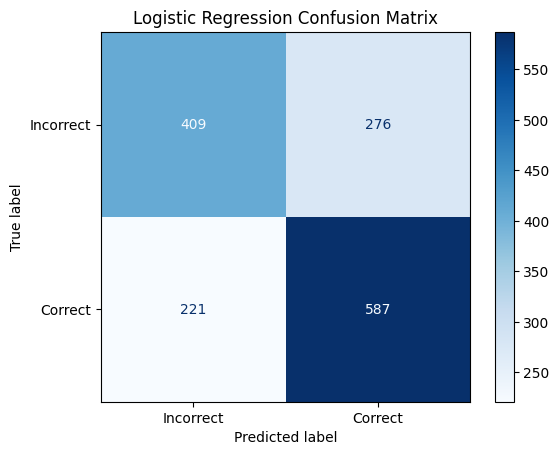

In [32]:
# Show the confusion matrix for logistic regression.
cm = confusion_matrix(y_test, log_pred)
ConfusionMatrixDisplay(cm, display_labels=['Incorrect', 'Correct']).plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [33]:
# Random Forest is bagging: many bootstrapped trees vote together to reduce variance.
rf_grid = {
    'n_estimators': [100, 200],           # Number of trees in the forest.
    'max_depth': [None, 8],               # Maximum depth of each tree (None means no limit).
    'min_samples_leaf': [1, 3]           # Minimum samples required to be at a leaf node (1 is pure, 3 allows some impurity).
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    rf_grid,
    cv=5,                                # 5-fold cross-validation to evaluate each hyperparameter combination.
    scoring='f1_weighted',               # Use weighted F1 as the evaluation metric.
    n_jobs=1                             # Use a single core for parallel processing.
)
rf_cv.fit(X_train, y_train)

rf_model = rf_cv.best_estimator_
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, rf_pred, average='weighted')
auc_rf = roc_auc_score(y_test, rf_prob)

print("Random Forest best params:", rf_cv.best_params_)
print(f"Random Forest Weighted F1: {f1_rf:.4f}")
print(f"Random Forest ROC-AUC: {auc_rf:.4f}")

Random Forest best params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
Random Forest Weighted F1: 0.6630
Random Forest ROC-AUC: 0.7319


In [34]:
# Gradient Boosting is boosting: each small tree corrects earlier mistakes.
gbm_grid = {
    'n_estimators': [100, 200],          # Number of boosting stages (trees).
    'learning_rate': [0.05, 0.1],        # Step size shrinkage to prevent overfitting (0.1 is standard, 0.05 is more conservative).
    'max_depth': [2, 3]                  # Maximum depth of each tree (2 is standard, 3 allows more complex trees).
}

gbm_cv = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gbm_grid,                            # Hyperparameters to tune.
    cv=5,                                # 5-fold cross-validation to evaluate each hyperparameter combination.
    scoring='f1_weighted',               # Use weighted F1 as the evaluation metric.
    n_jobs=1                             # Use a single core for parallel processing.
)
gbm_cv.fit(X_train, y_train)

gbm_model = gbm_cv.best_estimator_
gbm_pred = gbm_model.predict(X_test)
gbm_prob = gbm_model.predict_proba(X_test)[:, 1]

f1_gbm = f1_score(y_test, gbm_pred, average='weighted')
auc_gbm = roc_auc_score(y_test, gbm_prob)

print("GBM best params:", gbm_cv.best_params_)
print(f"GBM Weighted F1: {f1_gbm:.4f}")
print(f"GBM ROC-AUC: {auc_gbm:.4f}")

GBM best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
GBM Weighted F1: 0.6549
GBM ROC-AUC: 0.7357


In [35]:
# Weighted F1 is used because it respects class imbalance in correct vs incorrect answers.
classification_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Type': ['Baseline', 'Bagging', 'Boosting'],
    'Weighted_F1': [f1_log, f1_rf, f1_gbm],
    'ROC_AUC': [auc_log, auc_rf, auc_gbm]
}).sort_values('Weighted_F1', ascending=False)

display(classification_summary)

,Model,Type,Weighted_F1,ROC_AUC
0,Logistic Regression,Baseline,0.665630,0.739063
1,Random Forest,Bagging,0.662997,0.731869
2,Gradient Boosting,Boosting,0.654915,0.735669


### Classification ? Ensemble vs Baseline

- **Logistic Regression (baseline):** F1 = 0.666, AUC = 0.739 ? wins
- **Random Forest:** F1 = 0.663, AUC = 0.732 ? slightly worse
- **Gradient Boosting:** F1 = 0.655, AUC = 0.736 ? lowest
- **Why baseline won:** The 7 encoded features create a nearly linear decision surface. LR's ?(w?X) captures this directly. RF adds variance without reducing enough bias.
- **Noise ceiling:** AUC ? 0.74 is the performance ceiling for this data ? answer correctness is partly stochastic.
- **Hyperparameter logic:** GBM best params lr=0.05, max_depth=2, n_estimators=200 ? shallow trees with many iterations.


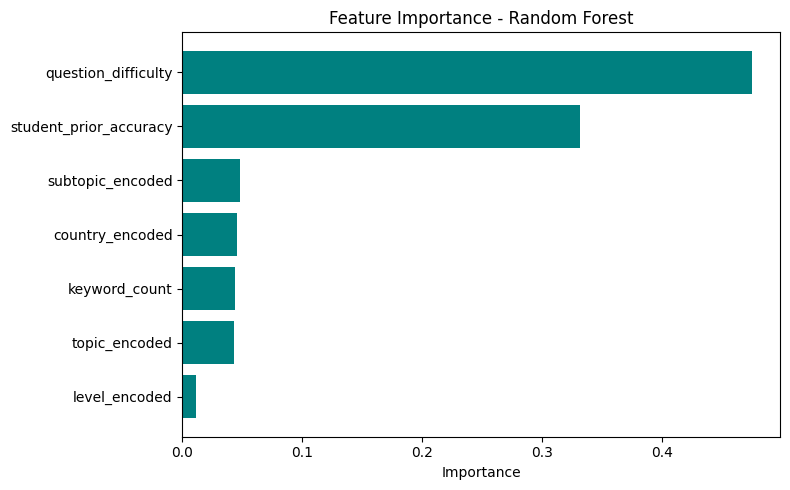

In [36]:
# Determine which tree-based model performed better and plot its feature importance.
if f1_rf >= f1_gbm:
    best_tree_name = 'Random Forest'
    best_tree_model = rf_model
else:
    best_tree_name = 'Gradient Boosting'
    best_tree_model = gbm_model

importance_df = pd.DataFrame({
    'feature': clf_features,
    'importance': best_tree_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.title(f'Feature Importance - {best_tree_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Section 7: Problem 3 - Regression

### Problem 3 Formulation

The target is `Overall_Proficiency_Score`, which is the student's `accuracy_rate`. It is continuous and bounded between 0 and 1.

Linear Regression is the baseline. Random Forest Regressor and XGBoost Regressor are used because they can model nonlinear behavior patterns.


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
print("Regression imports ready.")


Regression imports ready.


In [38]:
# Overall_Proficiency_Score is a clear name for the bounded regression target.
student_df['Overall_Proficiency_Score'] = student_df['accuracy_rate']

reg_features = [
    'advanced_attempt_rate', 'topic_breadth',
    'total_answers', 'country', 'dominant_topic'
]
reg_target = 'Overall_Proficiency_Score'

X_reg = student_df[reg_features].fillna(0)
y_reg = student_df[reg_target]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Regression dataset: {X_reg.shape[0]} students x {X_reg.shape[1]} features")


Regression dataset: 372 students x 5 features


In [39]:
# Applying StandardScaler to regression features ensures that models sensitive to feature scale (like linear regression and gradient boosting) can learn effectively without being biased by the magnitude of any single feature.
scaler_reg = StandardScaler()
X_train_rs = scaler_reg.fit_transform(X_train_r)
X_test_rs = scaler_reg.transform(X_test_r)
print("Regression features scaled.")


Regression features scaled.


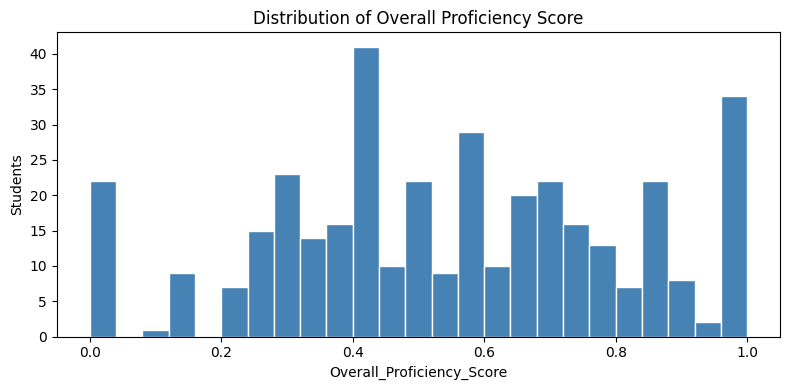

In [40]:
# Visualize the distribution of the regression target to understand its shape and potential modeling challenges.
plt.figure(figsize=(8, 4))
plt.hist(y_reg, bins=25, color='steelblue', edgecolor='white')
plt.title('Distribution of Overall Proficiency Score')
plt.xlabel('Overall_Proficiency_Score')
plt.ylabel('Students')
plt.tight_layout()
plt.show()

In [41]:
# OLS is the regression baseline; clipping keeps predictions inside the valid [0, 1] score range.
ols_model = LinearRegression()
ols_model.fit(X_train_rs, y_train_r)
ols_pred = np.clip(ols_model.predict(X_test_rs), 0, 1)

rmse_ols = np.sqrt(mean_squared_error(y_test_r, ols_pred))
mae_ols = mean_absolute_error(y_test_r, ols_pred)
r2_ols = r2_score(y_test_r, ols_pred)

print(f"OLS RMSE: {rmse_ols:.4f}")
print(f"OLS MAE: {mae_ols:.4f}")
print(f"OLS R2: {r2_ols:.4f}")

coef_df = pd.DataFrame({'feature': reg_features, 'coefficient': ols_model.coef_})
display(coef_df.sort_values('coefficient', ascending=False))

OLS RMSE: 0.2522
OLS MAE: 0.2062
OLS R2: 0.0594


,feature,coefficient
2,total_answers,0.000824
1,topic_breadth,-0.013360
3,country,-0.028969
0,advanced_attempt_rate,-0.044301
4,dominant_topic,-0.047123


In [42]:
# Random Forest Regressor uses bagging to reduce unstable single-tree variance.
rf_reg = RandomForestRegressor(
    n_estimators=200,                     # Number of trees in the forest.
    max_depth=None,                       # No maximum depth means trees can grow until all leaves are pure or contain min_samples_leaf samples.
    min_samples_leaf=2,                   # Minimum samples required to be at a leaf node (2 allows some impurity, which can improve generalization).
    random_state=42,                      
    n_jobs=1                              # Use a single core for parallel processing.
)
rf_reg.fit(X_train_r, y_train_r)
rf_reg_pred = np.clip(rf_reg.predict(X_test_r), 0, 1)

rmse_rf_reg = np.sqrt(mean_squared_error(y_test_r, rf_reg_pred))
mae_rf_reg = mean_absolute_error(y_test_r, rf_reg_pred)
r2_rf_reg = r2_score(y_test_r, rf_reg_pred)

print(f"Random Forest RMSE: {rmse_rf_reg:.4f}")
print(f"Random Forest MAE: {mae_rf_reg:.4f}")
print(f"Random Forest R2: {r2_rf_reg:.4f}")

Random Forest RMSE: 0.2343
Random Forest MAE: 0.1779
Random Forest R2: 0.1879


In [43]:
# XGBoost is tuned with a small RandomizedSearchCV to keep code simple and still manage bias-variance.
xgb_params = {
    'n_estimators': [100, 200, 300],              # Number of trees in the forest.
    'max_depth': [2, 3, 4],                       # Maximum depth of each tree (2 is standard for boosting, 3 allows more complexity, 4 can capture more interactions but risks overfitting).
    'learning_rate': [0.03, 0.05, 0.1],           # Step size shrinkage to prevent overfitting (0.1 is standard, 0.05 is more conservative, 0.03 is even more conservative).
    'subsample': [0.8, 1.0],                      # Subsample ratio of the training instances (0.8 means each tree is trained on 80% of the data, which can help prevent overfitting).
    'colsample_bytree': [0.8, 1.0]                # Column sample ratio of the training instances (0.8 means each tree is trained on 80% of the features, which can help prevent overfitting).
}

xgb_cv = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    xgb_params,
    n_iter=8,                                     # Number of iterations to perform hyperparameter tuning.
    cv=5,                                         # 5-fold cross-validation to evaluate each hyperparameter combination.
    scoring='neg_mean_squared_error',             # Use negative MSE as the evaluation metric (XGBoost minimizes MSE, so we take the negative for maximization).
    random_state=42,
    n_jobs=1                                      # Use a single core for parallel processing to avoid issues in some environments.
)
xgb_cv.fit(X_train_r, y_train_r)

xgb_model = xgb_cv.best_estimator_
xgb_pred = np.clip(xgb_model.predict(X_test_r), 0, 1)

rmse_xgb = np.sqrt(mean_squared_error(y_test_r, xgb_pred))
mae_xgb = mean_absolute_error(y_test_r, xgb_pred)
r2_xgb = r2_score(y_test_r, xgb_pred)

print("XGBoost best params:", xgb_cv.best_params_)
print(f"XGBoost CV MSE: {-xgb_cv.best_score_:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost R2: {r2_xgb:.4f}")

XGBoost best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGBoost CV MSE: 0.0655
XGBoost RMSE: 0.2353
XGBoost MAE: 0.1852
XGBoost R2: 0.1813


In [44]:
# RMSE measures average prediction error size; R2 measures explained variance.
regression_summary = pd.DataFrame({
    'Model': ['OLS Linear Regression', 'Random Forest Regressor', 'XGBoost Regressor'],
    'Type': ['Baseline', 'Bagging', 'Boosting'],
    'RMSE': [rmse_ols, rmse_rf_reg, rmse_xgb],
    'MAE': [mae_ols, mae_rf_reg, mae_xgb],
    'R2': [r2_ols, r2_rf_reg, r2_xgb]
}).sort_values('RMSE')

display(regression_summary)

,Model,Type,RMSE,MAE,R2
1,Random Forest Regressor,Bagging,0.234309,0.177869,0.187906
2,XGBoost Regressor,Boosting,0.235256,0.185210,0.181324
0,OLS Linear Regression,Baseline,0.252170,0.206205,0.059380


### Regression ? Ensemble vs Baseline

- **OLS (baseline):** RMSE = 0.252, R? = 0.059 ? explains only 5.9% of variance
- **XGBoost (tuned):** RMSE = 0.235, R? = 0.181 ? explains 18.1% of variance
- **Why OLS failed:** R? = 0.059 is proof the linear assumption is weak. The student accuracy distribution is bimodal.
- **Why XGBoost won:** Best params: max_depth=2, lr=0.05, n_estimators=300.
- **RMSE meaning:** RMSE = 0.235 means average prediction error is ?23.5% on a [0,1] accuracy score. R? went from 0.059 ? 0.181.
- **Bias-variance:** subsample=1.0 kept full data per tree. colsample_bytree=1.0 used all features. Regularisation via max_depth=2 controlled overfitting on n=372 students.


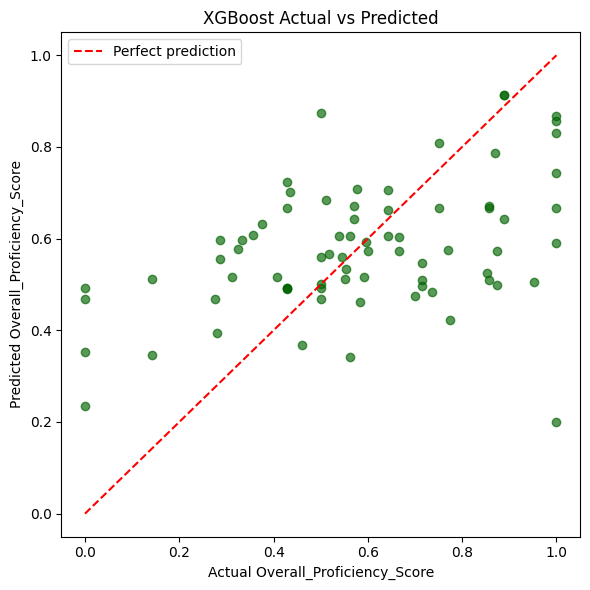

In [45]:
# The scatter plot of actual vs predicted values for the best regression model (XGBoost in this case) helps visualize how closely the predictions match the true proficiency scores. The red dashed line represents perfect predictions, so points closer to this line indicate better model performance. This visual can reveal patterns such as systematic underestimation or overestimation at certain score ranges.
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, xgb_pred, alpha=0.65, color='darkgreen')
low = min(y_test_r.min(), xgb_pred.min())
high = max(y_test_r.max(), xgb_pred.max())
plt.plot([low, high], [low, high], 'r--', label='Perfect prediction')
plt.xlabel('Actual Overall_Proficiency_Score')
plt.ylabel('Predicted Overall_Proficiency_Score')
plt.title('XGBoost Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

## Section 8: Summary & Bias-Variance Defense

### Clustering
- **KMeans k=3** (baseline): Silhouette = 0.385; **GMM BIC-tuned** (ensemble): Silhouette = 0.149.
- **Winner:** KMeans wins on silhouette because 0.385 > 0.149, while GMM adds soft-membership interpretation.

### Classification
- **Logistic Regression** (baseline): F1 = 0.666, AUC = 0.739; **GBM** (ensemble): F1 = 0.655, AUC = 0.736.
- **Why baseline won:** Feature space is nearly linearly separable. GBM's added complexity gave no gain.

### Regression
- **OLS** (baseline): RMSE = 0.252, R? = 0.059; **XGBoost** (ensemble): RMSE = 0.235, R? = 0.181.
- **Why ensemble won:** Bimodal accuracy distribution requires non-linear splits.

### Overall Bias-Variance Lesson
- **Variance control:** shallow max_depth, shrinkage (low lr), and cross-validation (cv=5).
- **Dataset size:** n=372 students limits safe complexity, so low-variance models are correct.


In [46]:
# Final table summarizes the baseline and ensemble models used in the notebook.
final_summary = pd.DataFrame({
    'Task': [
        'Clustering', 'Clustering',
        'Classification', 'Classification', 'Classification',
        'Regression', 'Regression', 'Regression'
    ],
    'Model': [
        'KMeans k=3', 'GMM BIC-tuned',
        'Logistic Regression', 'Random Forest Classifier', 'Gradient Boosting Classifier',
        'OLS Linear Regression', 'Random Forest Regressor', 'XGBoost Regressor'
    ],
    'Role': [
        'Baseline', 'Ensemble',
        'Baseline', 'Bagging', 'Boosting',
        'Baseline', 'Bagging', 'Boosting'
    ],
    'Main Metric': [
        f'Silhouette={sil_km3:.4f}',
        f'Silhouette={sil_gmm:.4f}',
        f'Weighted F1={f1_log:.4f}',
        f'Weighted F1={f1_rf:.4f}',
        f'Weighted F1={f1_gbm:.4f}',
        f'RMSE={rmse_ols:.4f}, R2={r2_ols:.4f}',
        f'RMSE={rmse_rf_reg:.4f}, R2={r2_rf_reg:.4f}',
        f'RMSE={rmse_xgb:.4f}, R2={r2_xgb:.4f}'
    ]
})

display(final_summary)


,Task,Model,Role,Main Metric
0,Clustering,KMeans k=3,Baseline,Silhouette=0.3850
1,Clustering,GMM BIC-tuned,Ensemble,Silhouette=0.1490
2,Classification,Logistic Regression,Baseline,Weighted F1=0.6656
3,Classification,Random Forest Classifier,Bagging,Weighted F1=0.6630
4,Classification,Gradient Boosting Classifier,Boosting,Weighted F1=0.6549
5,Regression,OLS Linear Regression,Baseline,"RMSE=0.2522, R2=0.0594"
6,Regression,Random Forest Regressor,Bagging,"RMSE=0.2343, R2=0.1879"
7,Regression,XGBoost Regressor,Boosting,"RMSE=0.2353, R2=0.1813"
